# IRROTATIONALITY, SHEAR AND ROTATION

'irrotational_shear_rotation_with_vectors.gif'

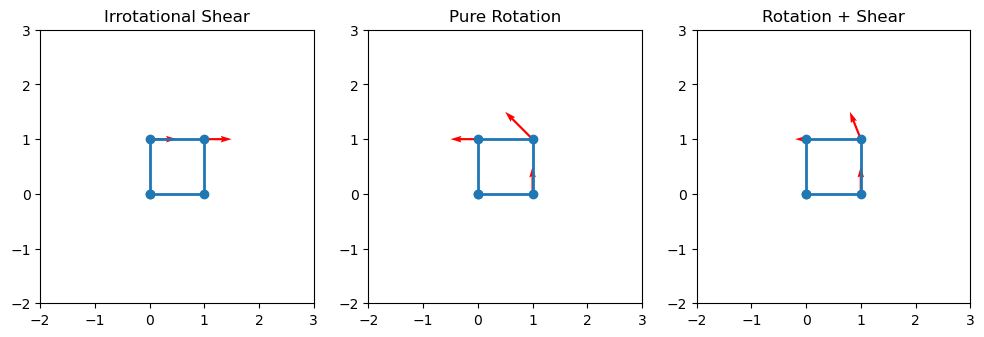

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ---- base geometry: 4 corners (no duplicate), and a closed path for plotting ----
rect4 = np.array([[0.0, 0.0],
                  [1.0, 0.0],
                  [1.0, 1.0],
                  [0.0, 1.0]])
rect_closed = np.vstack([rect4, rect4[0]])  # for line plotting

# ---- kinematics for three cases ----
def transform_and_velocity(corners, t, case):
    """Return transformed corners (4x2) and velocities (4x2) at time t for a case."""
    x, y = corners[:, 0], corners[:, 1]
    if case == "shear_only":
        # Irrotational shear: x += s*y, s oscillates
        s = 0.5 * np.sin(t)
        x_new = x + s * y
        y_new = y
        # Velocity: time derivative (ds/dt)*y with ds/dt = 0.5*cos(t)
        vx = 0.5 * np.cos(t) * y
        vy = np.zeros_like(y)
    elif case == "rotation_only":
        # Pure rigid-body rotation with angular speed w = 0.5
        w = 0.5
        theta = w * t
        R = np.array([[np.cos(theta), -np.sin(theta)],
                      [np.sin(theta),  np.cos(theta)]])
        pts = corners @ R.T
        x_new, y_new = pts[:, 0], pts[:, 1]
        # Velocity = w * zhat x r = (-w*y, w*x) in rotated frame
        vx = -w * y_new
        vy =  w * x_new
    elif case == "shear_plus_rotation":
        # Combine a smaller shear with rotation
        w = 0.5
        theta = w * t
        R = np.array([[np.cos(theta), -np.sin(theta)],
                      [np.sin(theta),  np.cos(theta)]])
        s = 0.3 * np.sin(t)
        S = np.array([[1.0, s],
                      [0.0, 1.0]])
        pts = corners @ S.T @ R.T
        x_new, y_new = pts[:, 0], pts[:, 1]
        # Approximate velocity by finite difference
        eps = 1e-3
        theta_e = w * (t + eps)
        R_e = np.array([[np.cos(theta_e), -np.sin(theta_e)],
                        [np.sin(theta_e),  np.cos(theta_e)]])
        s_e = 0.3 * np.sin(t + eps)
        S_e = np.array([[1.0, s_e],
                        [0.0, 1.0]])
        pts_e = corners @ S_e.T @ R_e.T
        vx = (pts_e[:, 0] - x_new) / eps
        vy = (pts_e[:, 1] - y_new) / eps
    else:
        raise ValueError("Unknown case")
    return np.column_stack([x_new, y_new]), np.column_stack([vx, vy])

# ---- figure and artists ----
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
cases  = ["shear_only", "rotation_only", "shear_plus_rotation"]
titles = ["Irrotational Shear", "Pure Rotation", "Rotation + Shear"]

lines = []
quivers = []
for ax, title in zip(axes, titles):
    # line for closed polygon
    line, = ax.plot([], [], '-o', lw=2)
    lines.append(line)
    # initialize quiver with 4 fixed arrows (one per corner)
    q = ax.quiver(rect4[:, 0], rect4[:, 1], np.zeros(4), np.zeros(4),
                  angles='xy', scale_units='xy', scale=1.0, color='red', width=0.008)
    quivers.append(q)
    ax.set_xlim(-2, 3)
    ax.set_ylim(-2, 3)
    ax.set_aspect('equal')
    ax.set_title(title)

def update(frame):
    t = frame / 20.0
    for ax, line, q, case in zip(axes, lines, quivers, cases):
        # transformed corners and velocities (4x2 each)
        pts4, vel4 = transform_and_velocity(rect4, t, case)
        # closed polygon for line plotting
        closed = np.vstack([pts4, pts4[0]])
        line.set_data(closed[:, 0], closed[:, 1])
        # update quiver: positions and (u,v) components; number of arrows stays 4
        q.set_offsets(pts4)
        q.set_UVC(vel4[:, 0], vel4[:, 1])
    return lines + quivers

anim = FuncAnimation(fig, update, frames=60, interval=100, blit=False)

# ---- save GIF ----
gif_path = "01_irrotational_shear_rotation_with_vectors.gif"
anim.save(gif_path, writer="pillow")
gif_path